In [1]:
# project 1st file 기본 전처리 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import preprocessing
importlib.reload(preprocessing)

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 

In [7]:
# 데이터 로드
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [8]:
from sklearn.preprocessing import StandardScaler


# 1. Amount 로그 변환 + StandardScaler 적용
df['Amount_log'] = np.log1p(df['Amount'])   # log(Amount+1)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount_log'].values.reshape(-1, 1))

# 원본 Amount, Amount_log 제거
df = df.drop(['Amount', 'Amount_log'], axis=1)


# 2. 특성과 타겟 분리 (Time 컬럼 제거)
X_features, y_target = pp.split_features_target(df, cols='Time')

# 3. 학습/테스트 분할
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [ ]:
# 3가지 샘플링 기법 적용

# SMOTE 오버샘플링
X_over, y_over = ds.oversampling_smote(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_over)}')
print(y_over.value_counts())

# 랜덤 언더샘플링
X_under, y_under = ds.undersampling_RUS(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_under)}')
print(y_under.value_counts())

# SMOTETomek 혼합 샘플링
X_combined, y_combined = ds.combined_sampling(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_combined)}')
print(y_combined.value_counts())

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
Before : 227845, After: 454902
Class
0    227451
1    227451
Name: count, dtype: int64
✅ 랜덤 언더샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 788 (Class 0: 394, Class 1: 394)
   제거된 샘플: 227057개
Before : 227845, After: 788
Class
0    394
1    394
Name: count, dtype: int64
✅ SMOTETomek 혼합 샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
   최종 변화: +227057개
Before : 227845, After: 454902
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
# 함수

# def preprocess_and_sampling(df):
#     """
#     데이터셋에서 Amount 컬럼을 로그 변환 + StandardScaler 적용 후
#     Time 컬럼 제거 → 학습/테스트 분할 → 3가지 샘플링 기법 적용
    
#     반환값:
#         X_train, X_test, y_train, y_test
#         X_over, y_over
#         X_under, y_under
#         X_combined, y_combined
#     """
#     # 1. Amount 로그 변환 + StandardScaler 적용
#     df['Amount_log'] = np.log1p(df['Amount'])   # log(Amount+1)
#     scaler = StandardScaler()
#     df['Amount_scaled'] = scaler.fit_transform(df['Amount_log'].values.reshape(-1, 1))

#     # 원본 Amount, Amount_log 제거
#     df = df.drop(['Amount', 'Amount_log'], axis=1)

#     # 2. 특성과 타겟 분리 (Time 제거)
#     X_features, y_target = pp.split_features_target(df, cols='Time')

#     # 3. 학습/테스트 분할
#     X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

#     # 4. 샘플링 기법 적용
#     # SMOTE 오버샘플링
#     X_over, y_over = ds.oversampling_smote(X_train, y_train)
#     print(f'[SMOTE] Before: {len(y_train)}, After: {len(y_over)}')
#     print(y_over.value_counts())

#     # 랜덤 언더샘플링
#     X_under, y_under = ds.undersampling_RUS(X_train, y_train)
#     print(f'[RUS] Before: {len(y_train)}, After: {len(y_under)}')
#     print(y_under.value_counts())

#     # SMOTETomek 혼합 샘플링
#     X_combined, y_combined = ds.combined_sampling(X_train, y_train)
#     print(f'[SMOTETomek] Before: {len(y_train)}, After: {len(y_combined)}')
#     print(y_combined.value_counts())

#     return (X_train, X_test, y_train, y_test,
#             X_over, y_over,
#             X_under, y_under,
#             X_combined, y_combine

'''
# 데이터 로드
df = pp.ccf_load_data()

# 함수 실행
X_train, X_test, y_train, y_test, \
X_over, y_over, \
X_under, y_under, \
X_combined, y_combined = preprocess_and_sampling(df)
'''

In [ ]:
# Logistic Regression base 모델에 각 3가지 샘플링 방법 적용
# 원본 포함 총 4개 결과 비교

from sklearn.linear_model import LogisticRegression

# 공통 모델 파라미터
lr_best_params = {
    "random_state": 23,
    'C': 0.029,
    'max_iter': 1000,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    "n_jobs": -1
}

# 학습/평가 함수 호출을 위한 데이터셋 목록
datasets = {
    "Original": (X_train, X_test, y_train, y_test),
    "SMOTE": (X_over, X_test, y_over, y_test),
    "UnderSampling": (X_under, X_test, y_under, y_test),
    "SMOTETomek": (X_combined, X_test, y_combined, y_test)
}

# 각 샘플링 방법별로 Logistic Regression 학습/평가
for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    model_name = f"LogisticRegression_AmountLog1pScaled_Timedrop_{name}_2025_11_26"
    lr_clf = LogisticRegression(**lr_best_params)
    uu.get_model_train_eval(lr_clf, model_name, X_tr, X_te, y_tr, y_te)

✓ 모델 저장 완료: ../models\LogisticRegression_AmountLog1pScaled_Timedrop_Original_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9590, 정확도: 0.9753, 정밀도: 0.0581, 재현율: 0.8776, F1: 0.1089
오차행렬:
[[55469  1395]
 [   12    86]]
실행 시간: 3.598992109298706
✓ 모델 저장 완료: ../models\LogisticRegression_AmountLog1pScaled_Timedrop_SMOTE_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9582, 정확도: 0.9741, 정밀도: 0.0555, 재현율: 0.8776, F1: 0.1044
오차행렬:
[[55401  1463]
 [   12    86]]
실행 시간: 3.393852710723877
✓ 모델 저장 완료: ../models\LogisticRegression_AmountLog1pScaled_Timedrop_UnderSampling_2025_11_26.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9676, 정확도: 0.9839, 정밀도: 0.0870, 재현율: 0.8776, F1: 0.1582
오차행렬:
[[55961   903]
 [   12    86]]
실행 시간: 2.0547211170196533
✓ 모델 저장 완료: ../models\LogisticRegression_AmountLog1pScaled_Timedrop_SMOTETomek_2025_1

        Sampling   ROC-AUC  Precision    Recall  F1-score
0       Original  0.959049   0.058069  0.877551  0.108930
1          SMOTE  0.958233   0.055520  0.877551  0.104432
2  UnderSampling  0.967585   0.086957  0.877551  0.158234
3     SMOTETomek  0.958233   0.055520  0.877551  0.104432


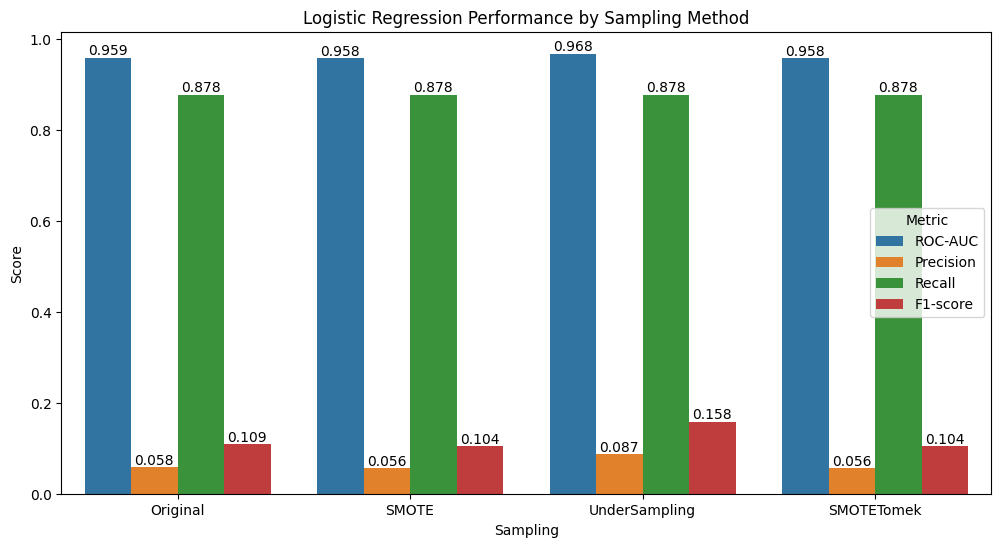

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression

# 공통 파라미터
lr_best_params = {
    "random_state": 23,
    'C': 0.029,
    'max_iter': 1000,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    "n_jobs": -1
}

# 데이터셋 목록
datasets = {
    "Original": (X_train, X_test, y_train, y_test),
    "SMOTE": (X_over, X_test, y_over, y_test),
    "UnderSampling": (X_under, X_test, y_under, y_test),
    "SMOTETomek": (X_combined, X_test, y_combined, y_test)
}

# 결과 저장용 리스트
results = []

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    lr_clf = LogisticRegression(**lr_best_params)
    lr_clf.fit(X_tr, y_tr)
    y_pred = lr_clf.predict(X_te)
    y_pred_proba = lr_clf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, y_pred_proba)
    recall = recall_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    results.append({
        "Sampling": name,
        "ROC-AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

# 결과 DataFrame
df_results = pd.DataFrame(results)
print(df_results)

# -----------------------------
# 📊 바차트 시각화 (수치 표시 포함)
# -----------------------------
plt.figure(figsize=(12,6))
df_melt = df_results.melt(id_vars="Sampling",
                          value_vars=["ROC-AUC","Precision","Recall","F1-score"],
                          var_name="Metric", value_name="Score")

ax = sns.barplot(data=df_melt, x="Sampling", y="Score", hue="Metric")

# 막대 위에 수치 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge")

plt.title("Logistic Regression Performance by Sampling Method")
plt.ylabel("Score")
plt.legend(title="Metric")
plt.show()

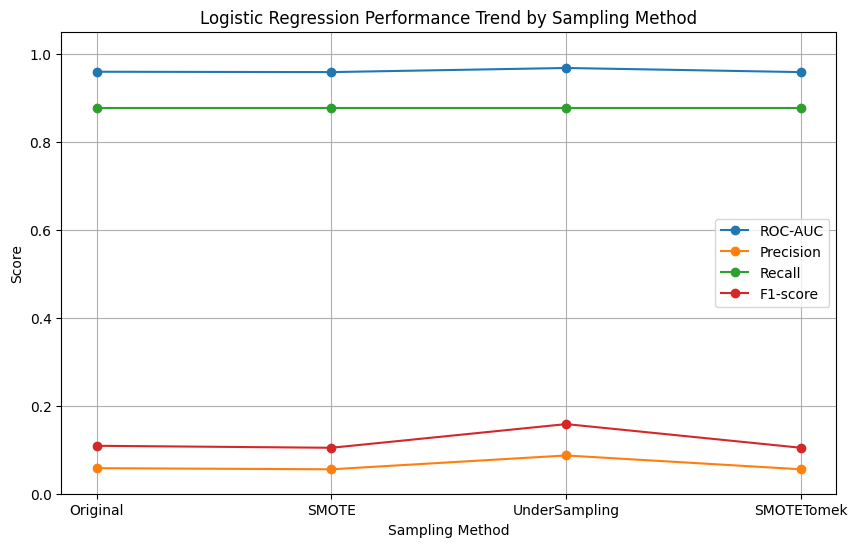

In [14]:
import matplotlib.pyplot as plt

# df_results는 이미 만들어진 성능 비교 DataFrame
# 예시: Sampling, ROC-AUC, Precision, Recall, F1-score 컬럼 포함

metrics = ["ROC-AUC", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(10,6))

for metric in metrics:
    plt.plot(df_results["Sampling"], df_results[metric],
             marker='o', label=metric)

plt.title("Logistic Regression Performance Trend by Sampling Method")
plt.xlabel("Sampling Method")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()